In [1]:
%load_ext autoreload
%autoreload 2

sampled 16 frames
visualizing


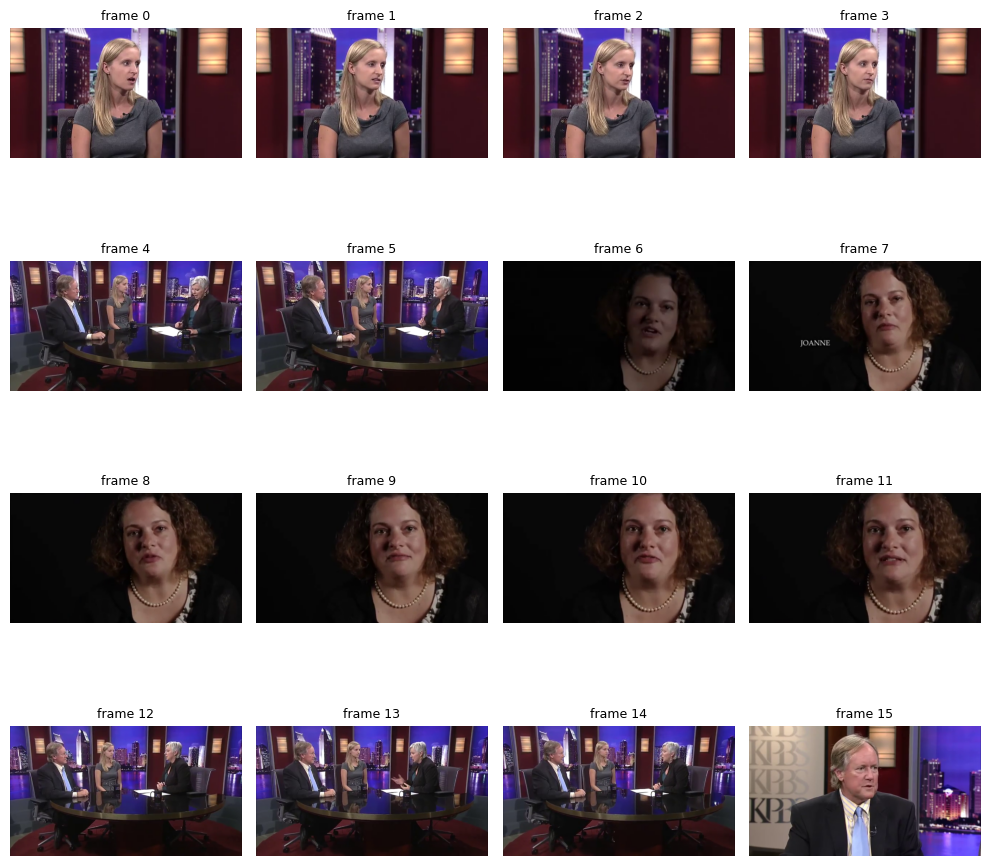

In [16]:
from src.social_memory.transforms.video import load_chunks, sample_frames


import matplotlib.pyplot as plt
import numpy as np
import math


def visualize_frames(frames, title=None, figsize=None, show_indices=True):
    """
    Plot sampled frames in a grid.

    Args:
        frames: list of HWC uint8 arrays (output of sample_frames), or a stacked
                ndarray of shape (N, H, W, C).
        title: optional figure title (e.g. video name or chunk path).
        figsize: optional (width, height) in inches. Auto-sized if None.
        show_indices: if True, label each subplot with its frame index.
    """
    if isinstance(frames, np.ndarray) and frames.ndim == 4:
        frames = list(frames)

    n = len(frames)
    if n == 0:
        print("No frames to visualize")
        return

    # Pick grid dims: 4x4 for n=16, otherwise as-square-as-possible
    if n == 16:
        rows, cols = 4, 4
    else:
        cols = math.ceil(math.sqrt(n))
        rows = math.ceil(n / cols)

    if figsize is None:
        figsize = (cols * 2.5, rows * 2.5)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()

    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(frames[i])
            if show_indices:
                ax.set_title(f"frame {i}", fontsize=9)
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    else:
        fig.tight_layout()

    plt.show()
    # return fig


chunk_path = "../chunks/w_WAB7TXtXQ/002.mp4"
frames = sample_frames(chunk_path, num_frames=16)
print(f'sampled {len(frames)} frames')
print('visualizing')
visualize_frames(frames)

In [5]:
from src.social_memory.adapters.xclipadapter import XCLIPAdapter

encoder = XCLIPAdapter(hidden_dim=512, output_dim=256).to("cuda")
encoder

/workspace/social-memory/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 591/591 [00:00<00:00, 1731.24it/s, Materializing param=visual_projection.weight]                                   
XCLIPModel LOAD REPORT from: microsoft/xclip-base-patch16-16-frames
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XCLIPAdapter(
  (backbone): XCLIPEncoder(
    (model): XCLIPModel(
      (text_model): XCLIPTextTransformer(
        (embeddings): XCLIPTextEmbeddings(
          (token_embedding): Embedding(49408, 512)
          (position_embedding): Embedding(77, 512)
        )
        (encoder): XCLIPEncoder(
          (layers): ModuleList(
            (0-11): 12 x XCLIPEncoderLayer(
              (self_attn): XCLIPAttention(
                (k_proj): Linear(in_features=512, out_features=512, bias=True)
                (v_proj): Linear(in_features=512, out_features=512, bias=True)
                (q_proj): Linear(in_features=512, out_features=512, bias=True)
                (out_proj): Linear(in_features=512, out_features=512, bias=True)
              )
              (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
              (mlp): XCLIPMLP(
                (activation_fn): QuickGELUActivation()
                (fc1): Linear(in_features=512, out_features=2048, bias=True)
    

In [6]:
import torch

# Only train the adapter params
trainable = [p for p in encoder.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable, lr=1e-4)

total = sum(p.numel() for p in encoder.parameters())
n_train = sum(p.numel() for p in trainable)
print(f"trainable: {n_train:,} / {total:,} ({100*n_train/total:.2f}%)")


trainable: 787,968 / 195,721,217 (0.40%)


In [ ]:
from src.social_memory.train import SIQ2LongDataset, collate_fn

dataset = SIQ2LongDataset(
    split='train',
    group_by_video=True,
    num_frames_per_video=16,
    max_chunks_per_video=24,
)


Dropping 143 videos with corrupt / too many chunks


[worker 85694] -99aZZhUgRk: 5 chunks, 0.67s


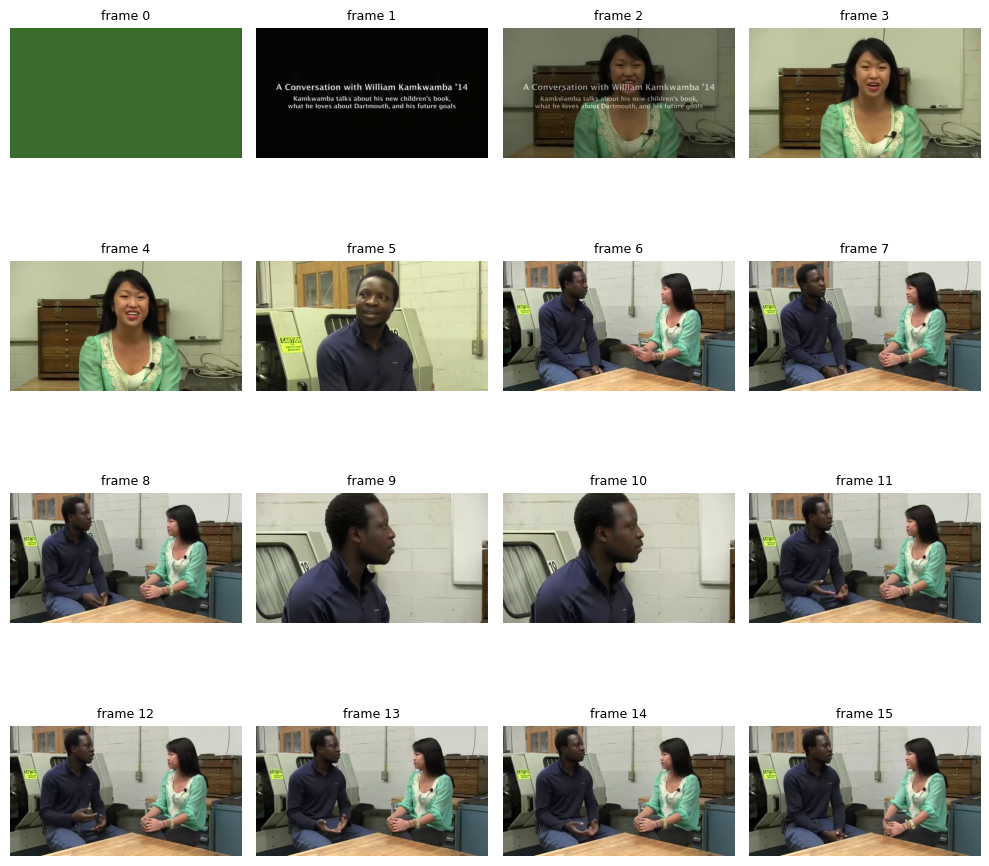

In [63]:

visualize_frames(dataset[0]['chunks'][0]['frames'])

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    # sampler=sampler,
    pin_memory=True,
    num_workers=8,          # start here, tune based on CPU count
    # prefetch_factor=4,      # each worker preloads 4 batches
    persistent_workers=False, # avoid re-spawning workers every epoch
    timeout=120,
)

In [ ]:
from src.social_memory.train import train

train(
    model=encoder,
    dataloader=dataloader,
    optimizer=optimizer,
    num_epochs=2,
)

GPU: NVIDIA H100 80GB HBM3
GPU memory: 85.0 GB

=== Epoch 1/2 ===


mmco: unref short failure
mmco: unref short failure


[worker 266622] 4LGe265pwvU: 4 chunks, 1.54s


mmco: unref short failure


[worker 266617] -99aZZhUgRk: 5 chunks, 2.33s
[worker 266619] 1YFLBjR-swo: 6 chunks, 2.94s
[worker 266624] 66ojfophGys: 9 chunks, 4.14s
[worker 266621] 3nUKwvFsjA4: 7 chunks, 5.85s
[worker 266617] -9NhaKWMtWU: 7 chunks, 4.00s


...

mmco: unref short failure


[worker 266622] 4Ry2bE-WRqA: 17 chunks, 9.51s
[worker 266618] 0SuGC2ifkIA: 10 chunks, 4.93s
[worker 266617] -bSM6iswghE: 6 chunks, 2.69s
[worker 266620] 2YGrrsKs-Xg: 18 chunks, 12.76s
[worker 266621] 3wIejfT9l30: 7 chunks, 3.23s
[worker 266622] 4VA4kqMnEqA: 6 chunks, 2.91s
[worker 266618] 0_8zVtd5VLY: 6 chunks, 2.69s
[worker 266619] 1Za8BtLgKv8: 12 chunks, 4.73s
[worker 266618] 0a2lv4IwZFY: 5 chunks, 1.70s
[worker 266622] 4Vic0qKl64Y: 6 chunks, 2.37s
[worker 266621] 3xdQIW24aj0: 6 chunks, 3.11s
[worker 266622] 4W192A7g5KY: 3 chunks, 1.12s
[worker 266622] 4_BudcPRi7E: 7 chunks, 0.61s
[worker 266624] 6rkV4QRcVnk: 15 chunks, 8.68s
[worker 266617] -hnBHBN8p5A: 20 chunks, 6.49s
[worker 266619] 1a4Gx6UHdI8: 13 chunks, 4.88s
[worker 266622] 4iw1jTY-X3A: 5 chunks, 1.66s
[worker 266624] 6tAfdCTnToY: 5 chunks, 1.80s
[worker 266617] -sp3Q524oO4: 4 chunks, 1.52s
[worker 266618] 0djStqAuc_E: 9 chunks, 4.39s
[worker 266617] 02A2a-aEvmI: 4 chunks, 1.27s
[worker 266622] 4tLBy9FGS5A: 8 chunks, 2.01s
[w

KeyboardInterrupt: 

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/workspace/social-memory/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/workspace/social-memory/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/workspace/social-memory/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/workspace/social-memory/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/root/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/root/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py", line 1961, in

: 